<a href="https://colab.research.google.com/github/AzaniFatturFadhika/2025_pengolahan_citra_TI2B/blob/main/Jobsheet05_MengukurKemiripanCitraDanPenerapannyaDalamPengenalanPola.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# JOBSHEET 05: MENGUKUR KEMIRIPAN CITRA DAN PENERAPANNYA DALAM PENGENALAN POLA
- Nama: Azani Fattur Fadhika
- NIM: 4.33.23.1.05
- Kelas: TI-2B

## Praktikum 1. Menghitung Jarak Berbasis Piksel (Euclidean & Manhattan)

Jarak Euclidean antara patch 1 dan patch 2: 24.7650
Jarak Euclidean antara patch 1 dan patch 3: 5.0000
Jarak Manhattan antara patch 1 dan patch 2: 936.4392
Jarak Manhattan antara patch 1 dan patch 3: 250.0000


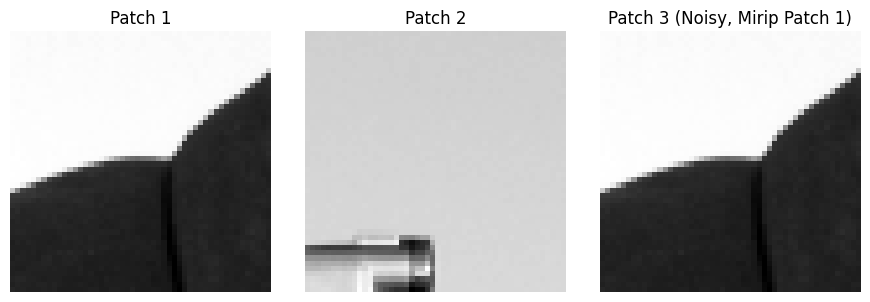

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance
from skimage import data, img_as_float

# 1. Buat dua patch citra sederhana atau ambil dari citra asli
image = img_as_float(data.camera())
patch1 = image[100:150, 100:150]  # Patch 1 dari citra asli
patch2 = image[100:150, 300:350]  # dati lokasi berbeda
patch3 = patch1 + 0.1 #  Patch 1 dengan noise sedikit/perubahan instance
patch3 = np.clip(patch3, 0, 1)  # Pastikan nilai tetap dalam rentang [0, 1]

# 2. Flattern patch menjadi vektor 1D
vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()

# 3. Hitung jarak Euclidean antara patch [L2]
dist_12_12 = distance.euclidean(vec1, vec2)  # Jarak antara patch 1 dan patch 2
dist_12_13 = distance.euclidean(vec1, vec3)  # Jarak antara patch 1 dan patch 3

# 4. Hitung jarak Manhattan antara patch [L1 - disebut 'cityblock' di scipy]
dist_11_12 = distance.cityblock(vec1, vec2)  # Jarak antara patch 1 dan patch 2
dist_11_13 = distance.cityblock(vec1, vec3)  # Jarak antara patch 1 dan patch 3

# 5. Tampilkan hasil dan patch
print(f"Jarak Euclidean antara patch 1 dan patch 2: {dist_12_12:.4f}")
print(f"Jarak Euclidean antara patch 1 dan patch 3: {dist_12_13:.4f}")
print(f"Jarak Manhattan antara patch 1 dan patch 2: {dist_11_12:.4f}")
print(f"Jarak Manhattan antara patch 1 dan patch 3: {dist_11_13:.4f}")

fig, ax = plt.subplots(1, 3, figsize=(9, 3))

ax[0].imshow(patch1, cmap='gray')
ax[0].set_title('Patch 1')
ax[0].axis('off')

ax[1].imshow(patch2, cmap='gray')
ax[1].set_title('Patch 2')
ax[1].axis('off')

ax[2].imshow(patch3, cmap='gray')
ax[2].set_title('Patch 3 (Noisy, Mirip Patch 1)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

## Praktikum 2. Menghitung Cosine Similarity antara Histogram Warna

Cosine Similarity antara citra 1 (Astronaut) dan citra 2 (Coffe): 0.8156
Cosine Similarity antara citra 1 (Astronaut) dan citra 3 (Astronaut): 1.0000
Cosine Similarity antara citra 1 (Astronaut) dan citra 4 (Astronaut Downsampled): 1.0000


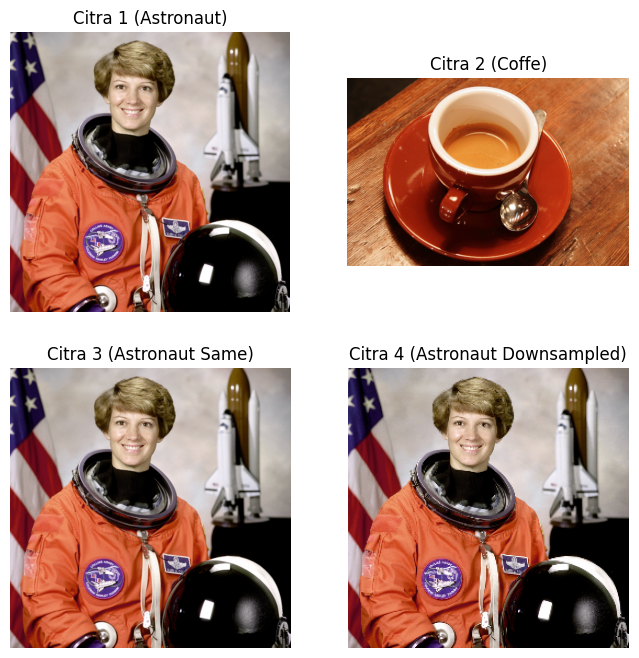

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance
from skimage import data, img_as_ubyte, io, color

# Fungsi untuk menghitung histogram RGB gabungan
def calculate_rgb_histogram(image, bins=16):
    img_uint8 = img_as_ubyte(image)  # Konversi citra ke uint8
    # Menghitung histogram untuk setiap channel warna
    hist_r, _ = np.histogram(image[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:, :, 2].ravel(), bins=bins, range=(0, 256))

    # Menggabungkan histogram R, G, B menjadi satu array veector fitur
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))
    # Normalisasi histogram
    hist_combined = hist_combined.astype('float') / np.sum(hist_combined)
    return hist_combined

# 1. Muat dua citra berwarna
try:
    # Gunakan citra berbeda dari skimage atau file lokal
    image1 = data.astronaut()  # Citra asli
    image2 = data.coffee()  # Citra asli lain
    image3 = data.astronaut()  # Citra sama untuk perbadingan
    image4 = image1[::2, ::2, :]  # Citra downsampled dari citra asli
except Exception as e:
    print(f"Error loading images: {e}")
    image1 = np.random.rand(100, 100, 3)
    image2 = np.random.rand(100, 100, 3) * 0.5
    image3 = image1.copy()
    image4 =image1[::2, ::2, :]  # Citra downsampled dari citra asli

# 2. Hitung histogram untuk setiap citra
hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)  # Citra sama
hist4 = calculate_rgb_histogram(image4)  # Citra downsampled

# 3. Hitung Cosine Similarity antara histogram (1 - Cosine distance)
#  scipy.spatial.distance.cosine menghitung jarak (1 - similarity)
sim_12 = 1 - distance.cosine(hist1, hist2)  # Similarity antara citra 1 dan citra 2
sim_13 = 1 - distance.cosine(hist1, hist3)  # Similarity antara citra 1 dan citra 3 (sama)
sim_14 = 1 - distance.cosine(hist1, hist4)  # Similarity antara citra 1 dan citra 4 (downsampled)

# 4. Tampilkan hasil
print(f"Cosine Similarity antara citra 1 (Astronaut) dan citra 2 (Coffe): {sim_12:.4f}")
print(f"Cosine Similarity antara citra 1 (Astronaut) dan citra 3 (Astronaut): {sim_13:.4f}")  # Harusnya tinggi
print(f"Cosine Similarity antara citra 1 (Astronaut) dan citra 4 (Astronaut Downsampled): {sim_14:.4f}")

# 5. Visualisasikan citra
fig, ax = plt.subplots(2, 2, figsize=(8, 8))
ax[0,0].imshow(image1)
ax[0,0].set_title('Citra 1 (Astronaut)')
ax[0,0].axis('off')
ax[0,1].imshow(image2)
ax[0,1].set_title('Citra 2 (Coffe)')
ax[0,1].axis('off')
ax[1,0].imshow(image3)
ax[1,0].set_title('Citra 3 (Astronaut Same)')
ax[1,0].axis('off')
ax[1,1].imshow(image4)
ax[1,1].set_title('Citra 4 (Astronaut Downsampled)')
ax[1,1].axis('off')

plt.show()

## Praktikum 3. Menghitung Structural Similarity Index (SSIM)


SSIM antara citra asli dan citra yang sama: 1.0000
SSIM antara citra asli dan citra dengan noise Gaussian: 0.2952
SSIM antara citra asli dan citra dengan kontras yang berbeda: 0.9651
SSIM antara citra asli dan citra yang diblur: 0.8742


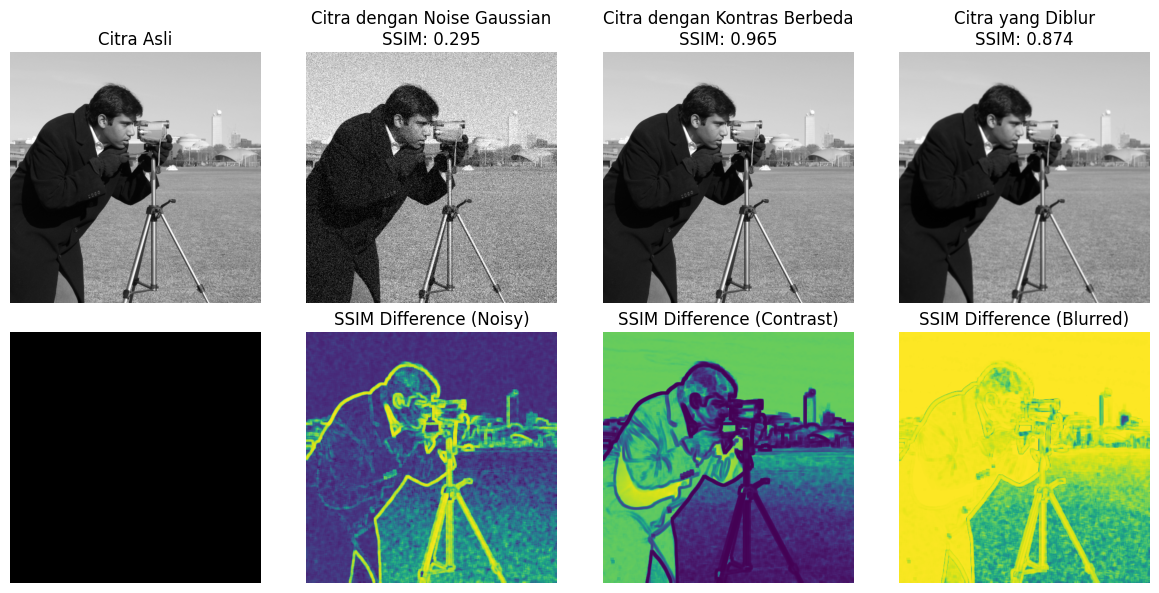

In [4]:
from cv2 import GaussianBlur
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.transform import resize
from skimage.util import random_noise

# 1. Muat dua citra asli
image = img_as_float(data.camera())  # Citra asli

# 2. Buat beberapa versi citra yang 'terdistorsi'
# a) Citra yang sama (SSIM harus 1)
image_same = image.copy()
# b) Citra dengan noise Gaussian
image_noise = random_noise(image, mode='gaussian', var=0.01)  # Tambahkan noise Gaussian
# c) Citra dengan kontras yang berbeda (dikali skalar)
image_contrast = np.clip(image * 0.8, 0, 1) # Kurangi kontras
# d) Citra yang diblur (blurred)
image_blurred = GaussianBlur(image, (3,3), sigmaX=1.5, sigmaY=1.5)  # Blur Gaussian

# 3. Hitung SSIM antara citra referensi dan citra terdistorsi
# Pastikan dimensi citra sama jika diperlukan
# SSIM memerlukan data_range
data_range = image.max() - image.min()

ssim_same, _ = ssim(image, image_same, data_range=data_range, full=True)  # SSIM antara citra asli dan citra yang sama
ssim_noisy, diff_noisy = ssim(image, image_noise, data_range=data_range, full=True)  # SSIM antara citra asli dan citra dengan noise Gaussian
ssim_contrast, diff_contrast = ssim(image, image_contrast, data_range=data_range, full=True)  # SSIM antara citra asli dan citra dengan kontras yang berbeda
ssim_blurred, diff_blurred = ssim(image, image_blurred, data_range=data_range, full=True)  # SSIM antara citra asli dan citra yang diblur
# 'full=True' mengembalikan SSIM dan citra perbandingan

# 4. Tampilkan hasil SSIM dan perbedaan SSIM juga
print(f"SSIM antara citra asli dan citra yang sama: {ssim_same:.4f}")
print(f"SSIM antara citra asli dan citra dengan noise Gaussian: {ssim_noisy:.4f}")
print(f"SSIM antara citra asli dan citra dengan kontras yang berbeda: {ssim_contrast:.4f}")
print(f"SSIM antara citra asli dan citra yang diblur: {ssim_blurred:.4f}")

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
ax = axes.ravel()
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Citra Asli')
ax[0].axis('off')
ax[1].imshow(image_noise, cmap='gray')
ax[1].set_title(f'Citra dengan Noise Gaussian\nSSIM: {ssim_noisy:.3f}')
ax[1].axis('off')
ax[2].imshow(image_contrast, cmap='gray')
ax[2].set_title(f'Citra dengan Kontras Berbeda\nSSIM: {ssim_contrast:.3f}')
ax[2].axis('off')
ax[3].imshow(image_blurred, cmap='gray')
ax[3].set_title(f'Citra yang Diblur\nSSIM: {ssim_blurred:.3f}')
ax[3].axis('off')

# Menampilkan peta perbedaan SSIM
ax[4].imshow(np.zeros_like(image), cmap='gray');
ax[4].set_title(''); ax[4].axis('off') # Placeholder
ax[5].imshow(diff_noisy, cmap='viridis'); ax[5].set_title('SSIM Difference (Noisy)'); ax[5].axis('off')
ax[6].imshow(diff_contrast, cmap='viridis'); ax[6].set_title('SSIM Difference (Contrast)'); ax[6].axis('off')
ax[7].imshow(diff_blurred, cmap='viridis'); ax[7].set_title('SSIM Difference (Blurred)'); ax[7].axis('off')


plt.tight_layout()
plt.show()

## Praktikum 4. Penerapan Template Matching

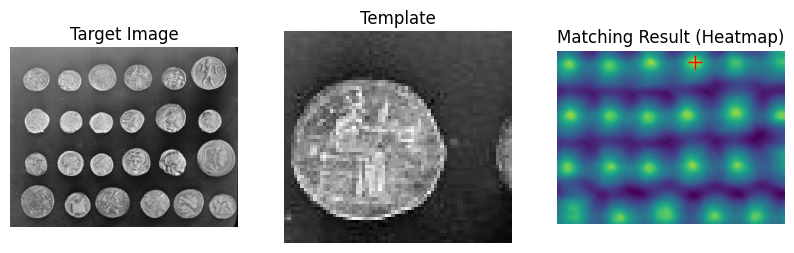

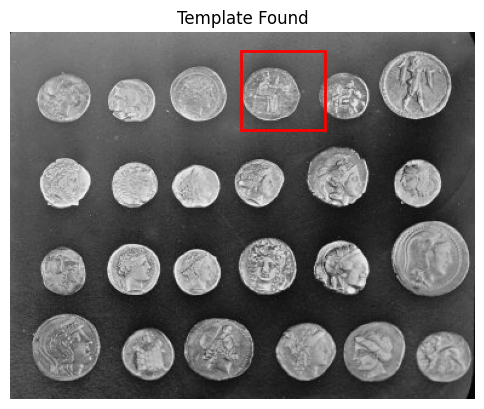

Template ditemukan di koordinat (x, y): (190, 15)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template

# 1. Muat citra target dan buat/muat citra template
image = data.coins()
template = image[15:80, 190:260]  # Ambil salah satu koin sebagai template

# 2. Lakukan template matching menggunakan Normalized Cross-Correlation (metode default)
result = match_template(image, template)

# 3. Temukan lokasi dengan skor matching tertinggi
ij = np.unravel_index(np.argmax(result), result.shape)  # Indeks linear ke koordinat 2D
x, y = ij[::-1]  # Koordinat (x, y) dari sudut kiri atas template yang cocok

# 4. Visualisasi hasil
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

# Tampilkan citra target
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].axis('off')

# Tampilkan template
ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template')
ax[1].axis('off')

# Tampilkan heatmap hasil matching
ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Matching Result (Heatmap)')
ax[2].axis('off')
ax[2].plot(x, y, 'r+', markersize=10)  # Tandai lokasi terbaik pada heatmap

# Tampilkan kotak di lokasi terbaik pada citra asli
fig2, ax_main = plt.subplots(figsize=(6, 6))
ax_main.imshow(image, cmap='gray')
ax_main.set_title('Template Found')
ax_main.axis('off')
h, w = template.shape
rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', lw=2)
ax_main.add_patch(rect)

plt.show()

print(f"Template ditemukan di koordinat (x, y): ({x}, {y})")

## Praktikum 5. Simulasi Content-Based Image Retrieval (CBIR) Sederhana


Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval (semakin ke kanan, semakin tidak mirip):
Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)


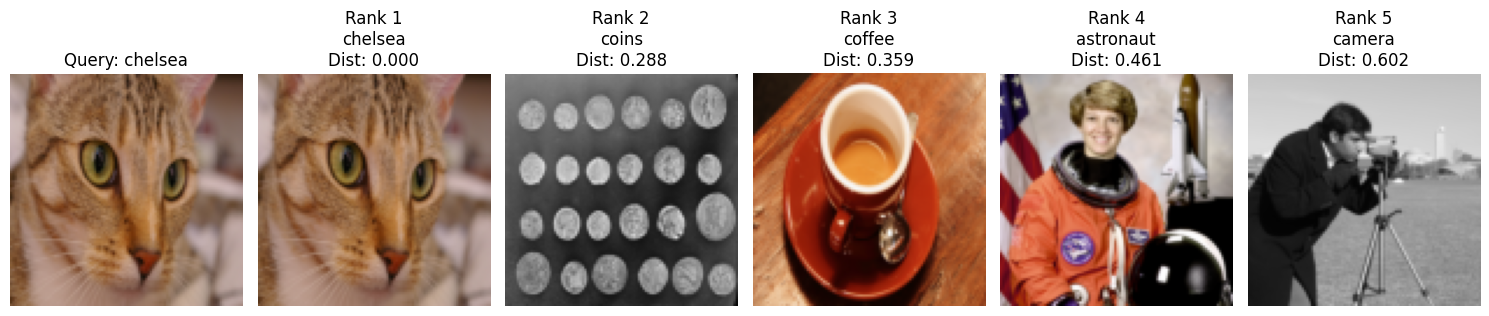

In [6]:
import numpy as np
from skimage import data, io, color, transform, img_as_float, img_as_ubyte
from scipy.spatial import distance

import matplotlib.pyplot as plt

# Fungsi hitung histogram dari Praktikum 2
def calculate_rgb_histogram(image, bins=16):
    # Pastikan input float [0,1] dikonversi ke uint8 [0,255] untuk histogram
    if image.dtype == float:
        image = img_as_ubyte(image)
    hist_r, _ = np.histogram(image[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:, :, 2].ravel(), bins=bins, range=(0, 256))
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))

    # Normalisasi L1 (sum to 1)
    hist_sum = np.sum(hist_combined)
    if hist_sum > 0:
        hist_combined = hist_combined.astype(float) / hist_sum
    else:
        hist_combined = hist_combined.astype(float)  # Hindari pembagian dengan nol
    return hist_combined

# 1. Siapkan 'database' citra kecil dan citra query
# Gunakan beberapa gambar dari skimage.data atau gambar Anda sendiri
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists = []

print("Memproses database citra...")
for name in image_db_names:
    try:
        img = getattr(data, name)()
        # Pastikan semua citra berwarna (RGB) dan ukuran sama (opsional, resize)
        if img.ndim == 2:  # Jika grayscale, konversi ke RGB
            img = color.gray2rgb(img)
        # Resize agar ukuran fitur konsisten (misal 100x100)
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
        database_images.append(img_resized)
        database_hists.append(calculate_rgb_histogram(img_resized))
        print(f"- {name} diproses.")
    except Exception as e:
        print(f"Error memproses {name}: {e}")

# Pilih satu citra sebagai query (misal, 'chelsea' si kucing)
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_hist = database_hists[query_index]

# 2. Hitung jarak/kemiripan antara query dan semua citra di database
# Kita gunakan Cosine Distance (1 - Cosine Similarity)
distances = []
for i, hist in enumerate(database_hists):
    dist = distance.cosine(query_hist, hist)
    distances.append(dist)

# 3. Urutkan citra berdasarkan jarak (dari terkecil ke terbesar)
sorted_indices = np.argsort(distances)

# 4. Tampilkan hasil: Query dan citra terurut berdasarkan kemiripan
num_results_to_show = len(database_images)
fig, axes = plt.subplots(1, num_results_to_show + 1, figsize=(15, 3))

# Tampilkan query
axes[0].imshow(query_image)
axes[0].set_title(f"Query: {query_image_name}")
axes[0].axis('off')

# Tampilkan hasil terurut
print("\nHasil Retrieval (semakin ke kanan, semakin tidak mirip):")
for i, idx in enumerate(sorted_indices):
    img_rank = i + 1  # Rank dimulai dari 1
    ax = axes[img_rank]  # Mulai dari plot ke-2
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {img_rank}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis('off')
    print(f"Rank {img_rank}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

# Matikan axes yang tidak terpakai jika num_results < len(db)
for j in range(num_results_to_show + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


## Penugasan

### Fitur Berbeda untuk CBIR:
- Modifikasi Praktikum 5. Alih-alih menggunakan histogram warna, coba gunakan fitur yang lebih sederhana seperti rata-rata warna (mean R, mean G, mean B) sebagai vektor fitur 3 dimensi.
- Hitung kemiripan menggunakan Jarak Euclidean (L_2) antara vektor fitur rata-rata warna ini. Bandingkan hasil retrievalnya dengan hasil yang menggunakan histogram. Manakah fitur yang lebih baik untuk membedakan citra-citra dalam database kecil tersebut?

In [7]:
import numpy as np
from skimage import data, color, transform
from scipy.spatial import distance
import matplotlib.pyplot as plt
from ipywidgets import interact, Dropdown

# Fungsi untuk menghitung rata-rata warna (mean R, G, B)
def calculate_mean_color(image):
    if image.ndim == 2:
        image = color.gray2rgb(image)
    return np.mean(image, axis=(0, 1))

# Fungsi untuk menghitung histogram warna (normalize ke range [0, 1])
def calculate_color_histogram(image, bins=16):
    hist_r, _ = np.histogram(image[:, :, 0], bins=bins, range=(0, 1), density=True)
    hist_g, _ = np.histogram(image[:, :, 1], bins=bins, range=(0, 1), density=True)
    hist_b, _ = np.histogram(image[:, :, 2], bins=bins, range=(0, 1), density=True)
    return np.concatenate([hist_r, hist_g, hist_b])

# Database citra
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
mean_color_features = []
histogram_features = []

# Load dan proses gambar
for name in image_db_names:
    img = getattr(data, name)()
    if img.ndim == 2:
        img = color.gray2rgb(img)
    img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
    database_images.append(img_resized)
    mean_color_features.append(calculate_mean_color(img_resized))
    histogram_features.append(calculate_color_histogram(img_resized))

# Fungsi interaktif untuk retrieval dan visualisasi
def retrieve_and_show(query_image_name):
    query_index = image_db_names.index(query_image_name)
    query_image = database_images[query_index]
    query_mean_feature = mean_color_features[query_index]
    query_hist_feature = histogram_features[query_index]

    # Hitung jarak Euclidean untuk mean color
    mean_distances = [distance.euclidean(query_mean_feature, f) for f in mean_color_features]
    sorted_mean_indices = np.argsort(mean_distances)

    # Hitung jarak Euclidean untuk histogram
    hist_distances = [distance.euclidean(query_hist_feature, f) for f in histogram_features]
    sorted_hist_indices = np.argsort(hist_distances)

    num_results = len(database_images)
    fig, axes = plt.subplots(3, num_results, figsize=(16, 8))

    # Baris 1: Query image di kolom pertama
    for col in range(num_results):
        if col == 0:
            axes[0, col].imshow(query_image)
            axes[0, col].set_title(f"Query:\n{query_image_name}")
        else:
            axes[0, col].axis('off')
        axes[0, col].axis('off')

    # Baris 2: Mean Color retrieval
    for i, idx in enumerate(sorted_mean_indices):
        axes[1, i].imshow(database_images[idx])
        axes[1, i].set_title(f"{image_db_names[idx]}\nDist: {mean_distances[idx]:.3f}")
        axes[1, i].axis('off')
    axes[1, 0].set_ylabel("Mean Color", fontsize=12)

    # Baris 3: Histogram retrieval
    for i, idx in enumerate(sorted_hist_indices):
        axes[2, i].imshow(database_images[idx])
        axes[2, i].set_title(f"{image_db_names[idx]}\nDist: {hist_distances[idx]:.3f}")
        axes[2, i].axis('off')
    axes[2, 0].set_ylabel("Histogram", fontsize=12)

    plt.tight_layout()
    plt.show()

# Dropdown interaktif untuk pilih query image
interact(retrieve_and_show, query_image_name=Dropdown(options=image_db_names, description='Query:'))


interactive(children=(Dropdown(description='Query:', options=('astronaut', 'camera', 'coffee', 'coins', 'chels…

<function __main__.retrieve_and_show(query_image_name)>

### Template Matching Invariant:
- Cari tahu dari dokumentasi skimage.feature.match_template atau sumber lain, apakah metode match_template standar invariant terhadap rotasi atau perubahan skala? Jelaskan
- (Petunjuk: Coba rotasi atau ubah ukuran template pada Praktikum 4 dan lihat hasilnya).

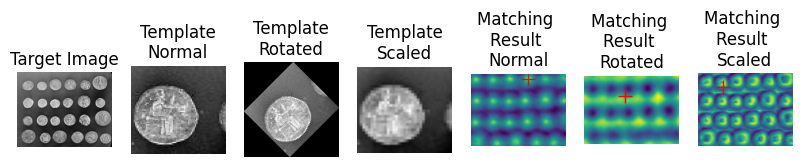

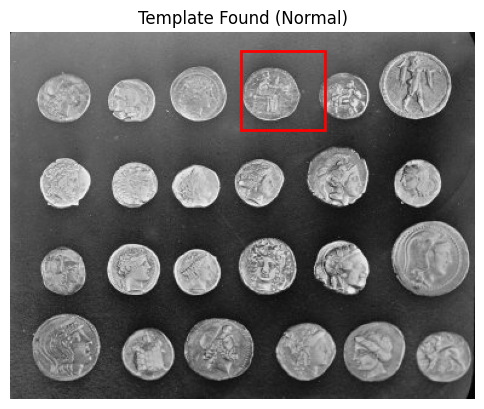

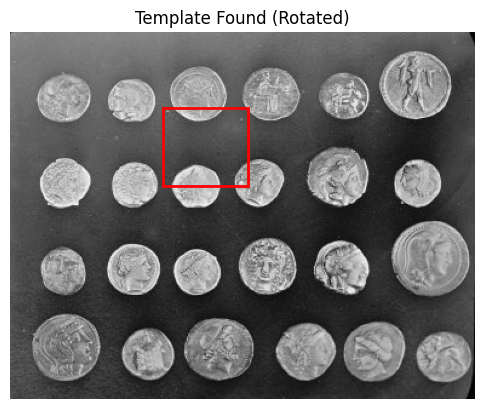

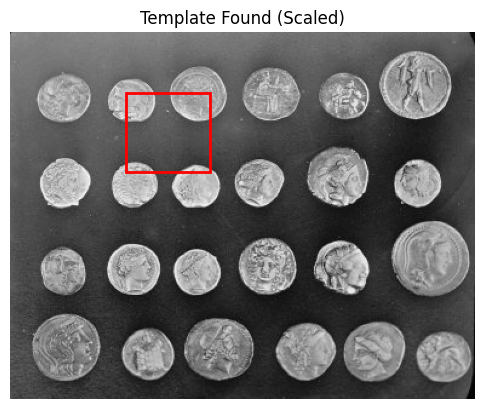

Skor maksimal normal : 1.000000000000001
Skor maksimal rotated : 0.6059281836718935
Skor maksimal scaled : 0.607171659345152


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template
from skimage.transform import rotate, rescale

# 1. Muat citra target dan buat/muat citra template
image = data.coins()  # Citra target
template = image[15:80, 190:260]  # Ambil salah satu koin sebagai template

# 2. Lakukan template matching menggunakan Normalized Cross-Correlation (metode default)
result = match_template(image, template)

# Uji dengan rotasi dan perubahan skala
rotated_template = rotate(template, angle=45, resize=True)  # Rotasi template
scaled_template = rescale(template, scale=0.5, anti_aliasing=True)  # Perubahan skala template

# Lakukan template matching dengan template yang dirotasi
result_rotated = match_template(image, rotated_template)
# Lakukan template matching dengan template yang diubah skalanya
result_scaled = match_template(image, scaled_template)

# 3. Temukan lokasi dengan skor matching tertinggi
ij = np.unravel_index(np.argmax(result), result.shape)  # Indeks linear ke koordinat 2D
ij2 = np.unravel_index(np.argmax(result_rotated), result.shape)  # Indeks linear ke koordinat 2D
ij3 = np.unravel_index(np.argmax(result_scaled), result.shape)  # Indeks linear ke koordinat 2D
x, y = ij[::-1]  # Koordinat (x, y) dari sudut kiri atas template yang cocok
x2, y2 = ij2[::-1]  # Koordinat (x2, y2) dari sudut kiri atas template yang cocok
x3, y3 = ij3[::-1]  # Koordinat (x3, y3) dari sudut kiri atas template yang cocok

# 4. Visualisasi hasil
fig, ax = plt.subplots(1, 7, figsize=(10, 4))

# Tampilkan citra target
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].axis('off')

# Tampilkan template
ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template\nNormal')
ax[1].axis('off')

# Tampilkan template rortasi
ax[2].imshow(rotated_template, cmap='gray')
ax[2].set_title('Template\nRotated')
ax[2].axis('off')

# Tampilkan template scaled
ax[3].imshow(scaled_template, cmap='gray')
ax[3].set_title('Template\nScaled')
ax[3].axis('off')

# Tampilkan heatmap hasil matching
ax[4].imshow(result, cmap='viridis')
ax[4].set_title('Matching \nResult \nNormal')
ax[4].axis('off')
ax[4].plot(x, y, 'r+', markersize=10)  # Tandai lokasi terbaik pada heatmap

# Tampilkan heatmap hasil matching rotated
ax[5].imshow(result_rotated, cmap='viridis')
ax[5].set_title('Matching \nResult \nRotated')
ax[5].axis('off')
ax[5].plot(x2, y2, 'r+', markersize=10)  # Tandai lokasi terbaik pada heatmap

# Tampilkan heatmap hasil matching scaled
ax[6].imshow(result_scaled, cmap='viridis')
ax[6].set_title('Matching \nResult \nScaled')
ax[6].axis('off')
ax[6].plot(x3, y3, 'r+', markersize=10)  # Tandai lokasi terbaik pada heatmap

# Kotak hasil normal
fig2, ax_main = plt.subplots(figsize=(6, 6))
ax_main.imshow(image, cmap='gray')
ax_main.set_title('Template Found (Normal)')
ax_main.axis('off')
h, w = template.shape
rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', lw=2)
ax_main.add_patch(rect)

# Kotak hasil rotated
fig3, ax_main2 = plt.subplots(figsize=(6, 6))
ax_main2.imshow(image, cmap='gray')
ax_main2.set_title('Template Found (Rotated)')
ax_main2.axis('off')
h, w = template.shape
rect = plt.Rectangle((x2, y2), w, h, edgecolor='r', facecolor='none', lw=2)
ax_main2.add_patch(rect)

# Kotak hasil scaled
fig4, ax_main3 = plt.subplots(figsize=(6, 6))
ax_main3.imshow(image, cmap='gray')
ax_main3.set_title('Template Found (Scaled)')
ax_main3.axis('off')
h, w = template.shape
rect = plt.Rectangle((x3, y3), w, h, edgecolor='r', facecolor='none', lw=2)
ax_main3.add_patch(rect)


plt.show()

print("Skor maksimal normal :", np.max(result))
print("Skor maksimal rotated :", np.max(result_rotated))
print("Skor maksimal scaled :", np.max(result_scaled))